# CFU plotting


In [2]:
import os
from pathlib import Path

import pandas as pd
from tqdm.auto import tqdm

# Plot

### Preliminary CFU results

In [27]:
rep1 = pd.DataFrame({
    'Treatment': ['H2O', 'DMSO', 'DMSO', 'RIF', 'RIF', 'RIF', 'RIF', 'PZA', 'PZA', 'PZA', 'PZA'],
    # 'Color': ['black', 'black', 'black', 'red', 'blue', 'black', 'green', 'orange', 'pink', 'purple', 'yellow'],
    'Lung CFU (log10)': [7.47, 5.73, 5.73, 4.88, 4.23, 5.16, 4.42, 3.48, 6.10, 3.73, 3.55],
    'rep_N': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    'mouse_N': [1, 2, 11, 3, 4, 6, 5, 8, 10, 7, 9]
})
rep2 = pd.DataFrame({
    'mouse_N': [3, 2, 1, 6, 5, 4, 9, 10, 11, 8, 7, 13, 12, 15, 14, 16],
    'Treatment': [
        'H2O', 'H2O', 'H2O', 
        'DMSO', 'DMSO', 'DMSO', 
        'RIF', 'RIF', 'RIF', 'RIF', 'RIF', 
        'PZA', 'PZA', 'PZA', 'PZA', 'PZA'
    ],
    # 'Color': [
    #     'red', None, None,    # Water Group (Mice 3, 2, 1)
    #     'black', 'green', 'blue', # DMSO Group (Mice 6, 5, 4)
    #     'yellow', 'pink', None, 'orange', 'purple', # RIF Group (Mice 9, 10, 11, 8, 7)
    #     None, None, None, None, None # PZA Group (Mice 13-16)
    # ],
    'Lung CFU (log10)': [6.36, 6.57, 6.50, 7.36, 6.12, 7.23, 5.47, 5.74, 6.52, 5.61, 5.64, 3.85, 7.29, 4.67, 4.36, 4.01],
    'rep_N': [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
})


cfu_df = pd.concat([rep1, rep2])
cfu_df

,Treatment,Lung CFU (log10),rep_N,mouse_N
0,H2O,7.47,1,1
1,DMSO,5.73,1,2
2,DMSO,5.73,1,11
3,RIF,4.88,1,3
4,RIF,4.23,1,4
5,RIF,5.16,1,6
6,RIF,4.42,1,5
7,PZA,3.48,1,8
8,PZA,6.10,1,10
9,PZA,3.73,1,7


# Final results

In [3]:
cfu_df = pd.DataFrame({
    "rep_mouse_id": [
        "1-1", "1-2", "1-11", "1-3", "1-4", "1-5", "1-6", "1-7", "1-8", "1-9", "1-10",
        "2-1", "2-2", "2-3", "2-4", "2-5", "2-6", "2-7", "2-8", "2-9", "2-10", "2-11",
        "2-12", "2-13", "2-14", "2-15", "2-16"
    ],
    "mouse_id": [
        1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11,
        12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27
    ],
    "condition": [
        "H2O", "DMSO", "DMSO", "RIF", "RIF", "RIF", "RIF", "PZA", "PZA", "PZA", "PZA",
        "H2O", "H2O", "H2O", "DMSO", "DMSO", "DMSO", "RIF", "RIF", "RIF", "RIF", "RIF",
        "PZA", "PZA", "PZA", "PZA", "PZA"
    ],
    "Lung CFU (log10)": [
        7.47, 5.75, 5.76, 4.87, 4.24, 4.41, 5.15, 3.78, 3.48, 3.56, 6.11,
        6.49, 6.57, 6.36, 7.23, 6.12, 7.36, 5.65, 5.61, 5.48, 5.75, 5.52,
        7.28, 3.86, 4.36, 4.69, 4.01
    ]
})
cfu_df[['rep_id', 'mouse_num']] = cfu_df['rep_mouse_id'].str.split('-', expand=True)
cfu_df

,rep_mouse_id,mouse_id,condition,Lung CFU (log10),rep_id,mouse_num
0,1-1,1,H2O,7.47,1,1
1,1-2,2,DMSO,5.75,1,2
2,1-11,3,DMSO,5.76,1,11
3,1-3,4,RIF,4.87,1,3
4,1-4,5,RIF,4.24,1,4
5,1-5,6,RIF,4.41,1,5
6,1-6,7,RIF,5.15,1,6
7,1-7,8,PZA,3.78,1,7
8,1-8,9,PZA,3.48,1,8
9,1-9,10,PZA,3.56,1,9


In [36]:
cfu_df.to_parquet('/mnt/OPERA3/Nathan/data/macrohet/mtb_tissue_localisation/results/CFUs.parquet')

In [37]:
cfu_df.to_json('/mnt/OPERA3/Nathan/data/macrohet/mtb_tissue_localisation/results/CFUs.json')

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

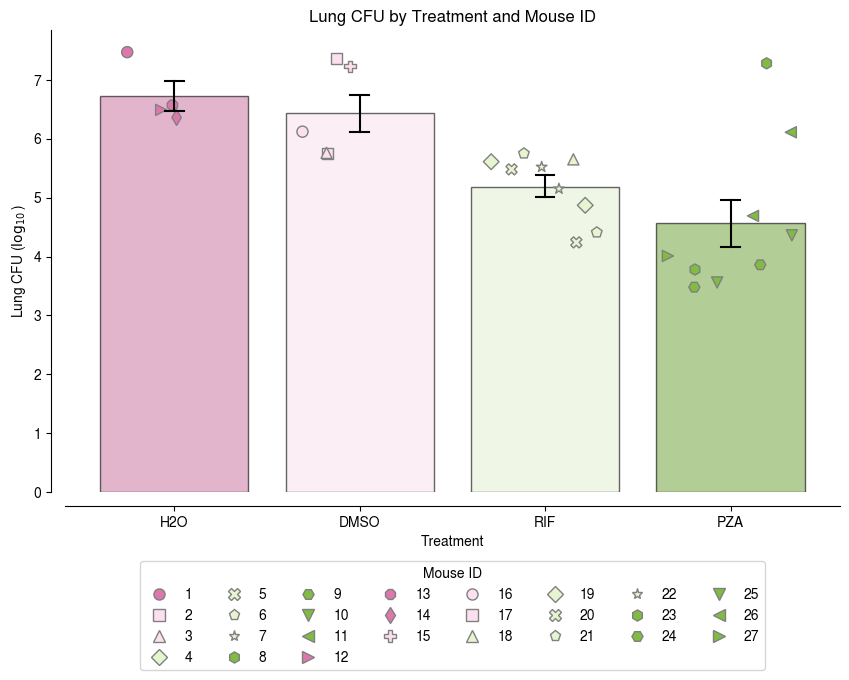

In [34]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
import numpy as np

# 1. Define Explicit Order
order = ['H2O', 'DMSO', 'RIF', 'PZA']

# 2. Define Condition Colors (PiYG)
# We map the specific order to the palette
palette_vals = sns.color_palette("PiYG", len(order))
condition_palette = dict(zip(order, palette_vals))

# 3. Define Marker Map
markers_list = ['o', 's', '^', 'D', 'X', 'p', '*', 'h', 'H', 'v', '<', '>', '8', 'd', 'P']
unique_ids = cfu_df['mouse_id'].unique()
marker_map = {mid: markers_list[i % len(markers_list)] for i, mid in enumerate(unique_ids)}

# 4. Create Mouse -> Color Mapping
id_to_condition = cfu_df[['mouse_id', 'condition']].drop_duplicates().set_index('mouse_id')['condition']

# 5. Jitter Calculation
# Map the explicit order to integers
cond_map = {cond: i for i, cond in enumerate(order)}
jitter_strength = 0.35
rng = np.random.default_rng()

# Ensure condition column matches the case of the order list if needed, otherwise direct map
cfu_df['x_jitter'] = cfu_df['condition'].map(cond_map) + rng.uniform(-jitter_strength, jitter_strength, size=len(cfu_df))

# Initialize Figure
f, ax = plt.subplots(figsize=(10, 6))

# 6. Bar Plot
sns.barplot(
    data=cfu_df,
    x='condition',
    y='Lung CFU (log10)',
    hue='condition',
    order=order,      # Enforces H2O -> DMSO -> RIF -> PZA
    ax=ax,
    palette=condition_palette,
    errorbar=('ci', 68),
    capsize=0.1,
    alpha=0.6,
    err_kws={'color': 'black', 'linewidth': 1.5},
    edgecolor='black',
    linewidth=1,
    legend=False
)

# 7. Scatter Plot
sns.scatterplot(
    data=cfu_df,
    x='x_jitter',
    y='Lung CFU (log10)',
    hue='condition',
    style='mouse_id',
    palette=condition_palette,
    markers=marker_map,
    s=64,
    edgecolor='gray',
    linewidth=1,
    ax=ax,
    legend=False
)

# 8. Construct Custom Legend Handles
legend_handles = []
# Sort IDs to ensure legend is somewhat organized (optional, can remove sorted())
for mid in sorted(unique_ids):
    cond = id_to_condition[mid]
    # Only create handle if condition is in our target list
    if cond in condition_palette:
        color = condition_palette[cond]
        marker = marker_map[mid]
        
        handle = mlines.Line2D(
            [], [], 
            color=color, 
            marker=marker, 
            linestyle='None', 
            markersize=8, 
            markeredgecolor='gray', 
            label=mid
        )
        legend_handles.append(handle)

# Refine Axes
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order)
ax.set_xlabel('Treatment')
ax.set_ylabel('Lung CFU ($\log_{10}$)')
ax.set_title('Lung CFU by Treatment and Mouse ID')

# Apply Custom Legend
ax.legend(
    handles=legend_handles,
    loc='lower center', 
    bbox_to_anchor=(0.5, -0.4), 
    ncol=8, 
    title='Mouse ID', 
    frameon=True
)

sns.despine(offset=10, trim=False)
ax.set_facecolor('white')

plt.savefig('/mnt/OPERA3/Nathan/data/macrohet/mtb_tissue_localisation/results/CFU_marker_style_separation.pdf', bbox_inches='tight', dpi=314)
plt.show()

/tmp/ipykernel_10735/4114103172.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


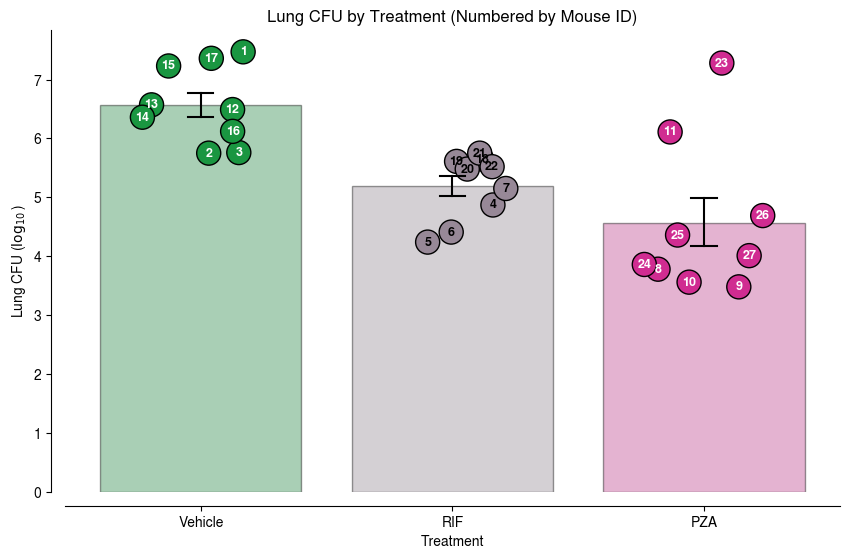

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set font for Ubuntu
plt.rcParams['font.family'] = 'Nimbus Sans'

# 1. Group Data and Define Order
cfu_df['plot_condition'] = cfu_df['condition'].replace(['H2O', 'DMSO'], 'Vehicle')
order = ['Vehicle', 'RIF', 'PZA']

# 2. Define Colors (Using expanded_piyg codes)
custom_colors = ['#1a9641', '#978897', '#d02c91']
condition_palette = dict(zip(order, custom_colors))

# 3. Jitter Calculation
cond_map = {cond: i for i, cond in enumerate(order)}
jitter_strength = 0.25
rng = np.random.default_rng()
cfu_df['x_jitter'] = cfu_df['plot_condition'].map(cond_map) + rng.uniform(-jitter_strength, jitter_strength, size=len(cfu_df))

# Initialize Figure
f, ax = plt.subplots(figsize=(10, 6))

# 4. Bar Plot
sns.barplot(
    data=cfu_df,
    x='plot_condition',
    y='Lung CFU (log10)',
    order=order,
    ax=ax,
    palette=condition_palette,
    errorbar=('ci', 68),
    capsize=0.1,
    alpha=0.4,
    err_kws={'color': 'black', 'linewidth': 1.5},
    edgecolor='black',
    linewidth=1,
    legend=False
)

# 5. Scatter Plot (Simple circles as backgrounds)
sns.scatterplot(
    data=cfu_df,
    x='x_jitter',
    y='Lung CFU (log10)',
    hue='plot_condition',
    hue_order=order,
    palette=condition_palette,
    marker='o',
    s=300, # Large size to act as a container for text
    edgecolor='black',
    linewidth=1,
    ax=ax,
    legend=False
)

# 6. Add Numbered Labels inside the circles
for i in range(len(cfu_df)):
    row = cfu_df.iloc[i]
    # Contrast logic for text color
    text_color = 'white' if row['plot_condition'] in ['Vehicle', 'PZA'] else 'black'
    
    ax.text(
        x=row['x_jitter'],
        y=row['Lung CFU (log10)'],
        s=str(int(row['mouse_id'])),
        fontsize=9,
        color=text_color,
        ha='center',
        va='center',
        fontweight='bold'
    )

# 7. Refine Axes
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order)
ax.set_xlabel('Treatment')
ax.set_ylabel('Lung CFU ($\log_{10}$)')
ax.set_title('Lung CFU by Treatment (Numbered by Mouse ID)')

sns.despine(offset=10)
ax.set_facecolor('white')

plt.savefig('/mnt/OPERA3/Nathan/data/macrohet/mtb_tissue_localisation/results/CFU_numbered_circles.pdf', bbox_inches='tight', dpi=314)
plt.show()

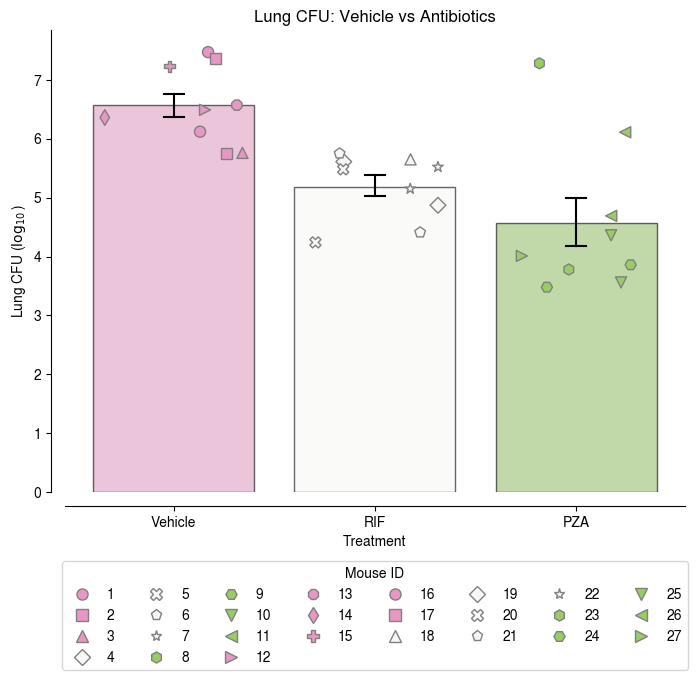

In [35]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
import numpy as np

# 1. Remap Data to 'Vehicle'
# We create a specific column for plotting to preserve original data integrity
cfu_df['plot_condition'] = cfu_df['condition'].replace(['H2O', 'DMSO'], 'Vehicle')
order = ['Vehicle', 'RIF', 'PZA']

# 2. Define Condition Colors (PiYG)
# We need 3 colors now. We can slice PiYG or pick specific ones.
# Using a 3-color slice of PiYG to maintain theme.
palette_vals = sns.color_palette("PiYG", len(order))
condition_palette = dict(zip(order, palette_vals))

# 3. Define Marker Map (Reuse existing logic)
markers_list = ['o', 's', '^', 'D', 'X', 'p', '*', 'h', 'H', 'v', '<', '>', '8', 'd', 'P']
unique_ids = cfu_df['mouse_id'].unique()
marker_map = {mid: markers_list[i % len(markers_list)] for i, mid in enumerate(unique_ids)}

# 4. Create Mouse -> New Condition Color Mapping
# We map based on the NEW plot_condition
id_to_condition = cfu_df[['mouse_id', 'plot_condition']].drop_duplicates().set_index('mouse_id')['plot_condition']

# 5. Jitter Calculation
cond_map = {cond: i for i, cond in enumerate(order)}
jitter_strength = 0.35
rng = np.random.default_rng()
cfu_df['x_jitter'] = cfu_df['plot_condition'].map(cond_map) + rng.uniform(-jitter_strength, jitter_strength, size=len(cfu_df))

# Initialize Figure
f, ax = plt.subplots(figsize=(8, 6))

# 6. Bar Plot
sns.barplot(
    data=cfu_df,
    x='plot_condition',
    y='Lung CFU (log10)',
    hue='plot_condition',
    order=order,
    ax=ax,
    palette=condition_palette,
    errorbar=('ci', 68),
    capsize=0.1,
    alpha=0.6,
    err_kws={'color': 'black', 'linewidth': 1.5},
    edgecolor='black',
    linewidth=1,
    legend=False
)

# 7. Scatter Plot
sns.scatterplot(
    data=cfu_df,
    x='x_jitter',
    y='Lung CFU (log10)',
    hue='plot_condition',
    style='mouse_id',
    palette=condition_palette,
    markers=marker_map,
    s=64,
    edgecolor='gray',
    linewidth=1,
    ax=ax,
    legend=False
)

# 8. Construct Custom Legend Handles
legend_handles = []
for mid in sorted(unique_ids):
    # Ensure we only plot IDs that exist in the current view
    if mid in id_to_condition:
        cond = id_to_condition[mid]
        if cond in condition_palette:
            color = condition_palette[cond]
            marker = marker_map[mid]
            
            handle = mlines.Line2D(
                [], [], 
                color=color, 
                marker=marker, 
                linestyle='None', 
                markersize=8, 
                markeredgecolor='gray', 
                label=mid
            )
            legend_handles.append(handle)

# Refine Axes
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order)
ax.set_xlabel('Treatment')
ax.set_ylabel('Lung CFU ($\log_{10}$)')
ax.set_title('Lung CFU: Vehicle vs Antibiotics')

# Apply Custom Legend
ax.legend(
    handles=legend_handles,
    loc='lower center', 
    bbox_to_anchor=(0.5, -0.4), 
    ncol=8, 
    title='Mouse ID', 
    frameon=True
)

sns.despine(offset=10, trim=False)
ax.set_facecolor('white')

plt.savefig('/mnt/OPERA3/Nathan/data/macrohet/mtb_tissue_localisation/results/CFU_Vehicle_Merged.pdf', bbox_inches='tight', dpi=314)
plt.show()

/tmp/ipykernel_10735/929881125.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


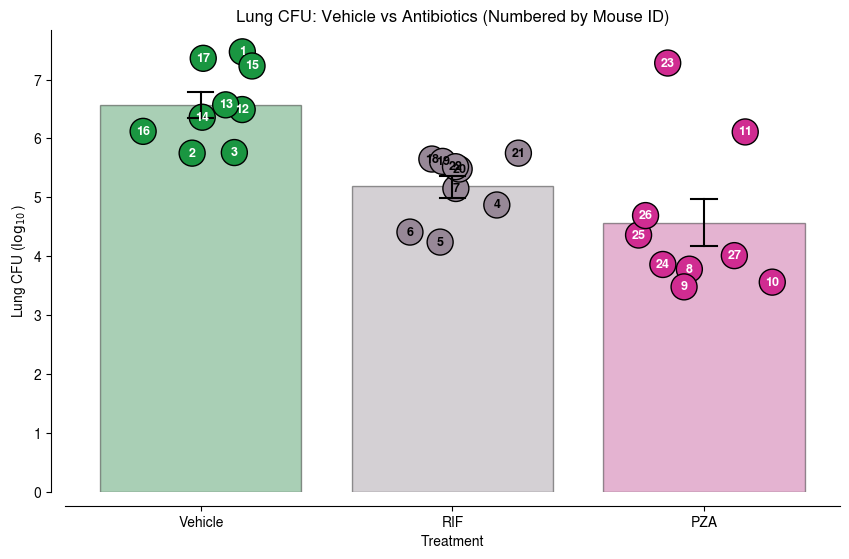

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set font for Ubuntu
plt.rcParams['font.family'] = 'Nimbus Sans'

# 1. Remap Data to 'Vehicle'
cfu_df['plot_condition'] = cfu_df['condition'].replace(['H2O', 'DMSO'], 'Vehicle')
order = ['Vehicle', 'RIF', 'PZA']

# 2. Define Condition Colors (PiYG)
# Using your preferred PiYG expanded palette: Green, Grey, Pink
custom_colors = ['#1a9641', '#978897', '#d02c91']
condition_palette = dict(zip(order, custom_colors))

# 3. Jitter Calculation
cond_map = {cond: i for i, cond in enumerate(order)}
jitter_strength = 0.28  # Slightly tighter jitter for better grouping
rng = np.random.default_rng()
cfu_df['x_jitter'] = cfu_df['plot_condition'].map(cond_map) + rng.uniform(-jitter_strength, jitter_strength, size=len(cfu_df))

# Initialize Figure
f, ax = plt.subplots(figsize=(10, 6))

# 4. Bar Plot
sns.barplot(
    data=cfu_df,
    x='plot_condition',
    y='Lung CFU (log10)',
    order=order,
    ax=ax,
    palette=condition_palette,
    errorbar=('ci', 68),
    capsize=0.1,
    alpha=0.4, # Lighter bars to let the numbered circles pop
    err_kws={'color': 'black', 'linewidth': 1.5},
    edgecolor='black',
    linewidth=1,
    legend=False
)

# 5. Scatter Plot (Serving as the circle background)
sns.scatterplot(
    data=cfu_df,
    x='x_jitter',
    y='Lung CFU (log10)',
    hue='plot_condition',
    hue_order=order,
    palette=condition_palette,
    marker='o',
    s=350, # Large size to contain the text
    edgecolor='black',
    linewidth=1,
    ax=ax,
    legend=False
)

# 6. Overlay Mouse ID Numbers
for i in range(len(cfu_df)):
    row = cfu_df.iloc[i]
    # Contrast: Use white text for dark Green (Vehicle) and Dark Pink (PZA)
    text_color = 'white' if row['plot_condition'] in ['Vehicle', 'PZA'] else 'black'
    
    ax.text(
        x=row['x_jitter'],
        y=row['Lung CFU (log10)'],
        s=str(int(row['mouse_id'])),
        fontsize=9,
        color=text_color,
        ha='center',
        va='center',
        fontweight='bold'
    )

# 7. Refine Axes
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order)
ax.set_xlabel('Treatment')
ax.set_ylabel('Lung CFU ($\log_{10}$)')
ax.set_title('Lung CFU: Vehicle vs Antibiotics (Numbered by Mouse ID)')

sns.despine(offset=10)
ax.set_facecolor('white')

plt.savefig('/mnt/OPERA3/Nathan/data/macrohet/mtb_tissue_localisation/results/CFU_Vehicle_Numbered.pdf', bbox_inches='tight', dpi=314)
plt.show()

## Previous results

/tmp/ipykernel_704808/3492075298.py:48: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
/tmp/ipykernel_704808/3492075298.py:48: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
/tmp/ipykernel_704808/3492075298.py:48: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
/tmp/ipykernel_704808/3492075298.py:48: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
/tmp/ipykernel_704808/3492075298.py:48: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
/tmp/ipykernel_704808/3492075298.py:48: FutureWarning: Use "auto" to set automatic grayscale colors.

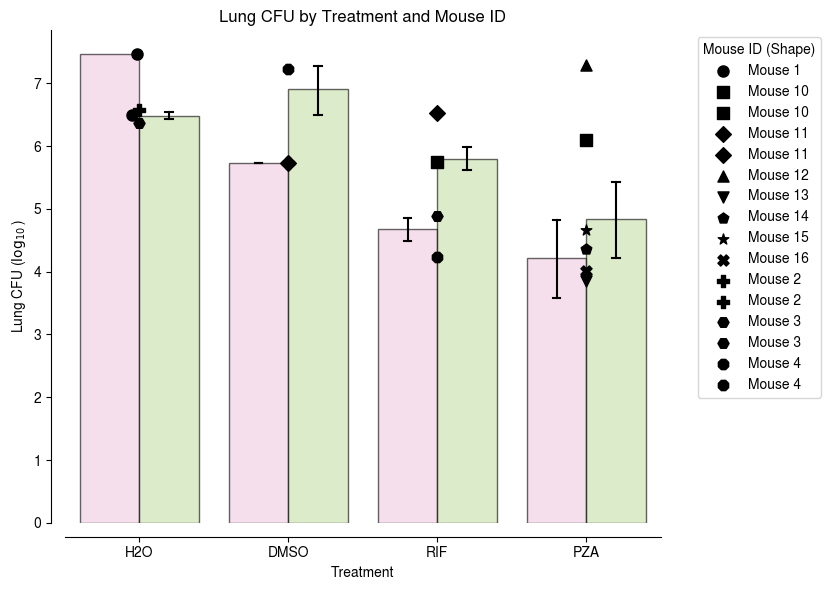

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Prepare Data and Mappings ---

# Get unique 'mouse_N' values and ensure they are strings for robust mapping
mouse_N_values = sorted(cfu_df['mouse_N'].astype(str).unique())

# Define the markers you want to use. Make sure this list is long enough
# for all your unique 'mouse_N' values.
all_markers = ['o', 's', 'D', '^', 'v', 'p', '*', 'X', 'P', 'H', '8']

# Create a dictionary to map 'mouse_N' value -> marker shape
marker_map = dict(zip(mouse_N_values, all_markers[:len(mouse_N_values)]))

# --- 2. Setup Plot ---

plt.figure(figsize=(10, 6))
ax = plt.gca()

# 1. Bar Plot for the mean (Average CFU per Treatment)
# Set hue to 'Treatment' so the bar colors are based on the x-axis groups.
sns.barplot(
    data=cfu_df,
    x='Treatment',
    y='Lung CFU (log10)',
    hue='rep_N',  # Use treatment for hue to get colored bars
    ax=ax,
    errorbar=('ci', 68),
    capsize=0.1,
    alpha=0.6,
    err_kws={'color': 'black', 'linewidth': 1.5},
    edgecolor='black',
    linewidth=1,
    # hue='Treatment',
    palette='PiYG', # Optional: uncomment if you want a specific color palette
    legend=False # Hide the barplot legend
)

# 2. Scatter Plot for individual data points (Iterating for manual style)
# We need to iterate over mouse_N groups to set the 'marker' shape
for mouse_n_val, marker_shape in marker_map.items():
    
    # Filter data for the current mouse_N
    subset_data = cfu_df[cfu_df['mouse_N'].astype(str) == mouse_n_val]
    
    # Plot the subset with the specified marker
    sns.stripplot(
        data=subset_data,
        x='Treatment',
        y='Lung CFU (log10)',
        ax=ax,
        color='black',       # Use a single color for points, or use a hue column here if desired
        size=8,
        jitter=0.2,
        linewidth=1,
        marker=marker_shape, # <-- THIS IS THE KEY MANUAL STEP
        edgecolor='gray',
        # Add a label for the legend (only one label per mouse_n_val)
        label=f'Mouse {mouse_n_val}' 
    )

# --- 3. Legend Cleanup ---

# The stripplots already generated a legend entry via the 'label' argument.
# We just need to finalize and position it.
ax.legend(
    title='Mouse ID (Shape)', 
    loc='upper left', 
    bbox_to_anchor=(1.05, 1)
)
sns.despine(offset=10)
# Final Touches
plt.title('Lung CFU by Treatment and Mouse ID')
plt.xlabel('Treatment')
plt.ylabel('Lung CFU ($\log_{10}$)')
plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust to fit the legend
plt.savefig('/mnt/OPERA3/Nathan/data/macrohet/mtb_tissue_localisation/results/CFU_bar_and_marker_style_separation.pdf', bbox_inches='tight', dpi=314)

plt.show()

/tmp/ipykernel_704808/3363146142.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_704808/3363146142.py:23: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(


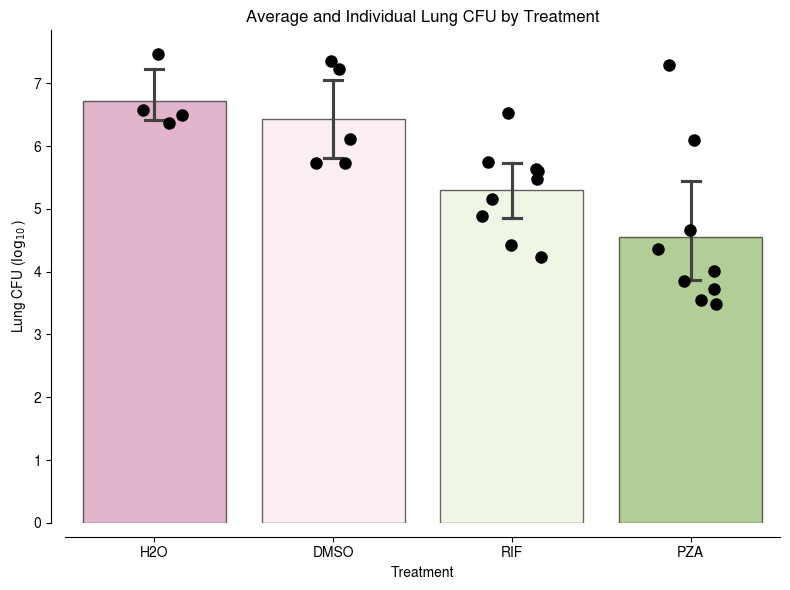

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
ax = plt.gca()

# 1. Bar Plot for the mean (Average CFU per Treatment)
# The hue is set to 'Treatment' to color the bars, which simplifies the stripplot later.
sns.barplot(
    data=cfu_df,
    x='Treatment',
    y='Lung CFU (log10)',
    ax=ax,
    # errorbar=('ci', 68),  # Shows Mean +/- 1 Standard Error (SEM)
    capsize=0.1,
    alpha=0.6,            # Make the bars slightly transparent
    edgecolor='black',
    linewidth=1,
    palette='PiYG' # Optional: uncomment if you want a specific color palette
)

# 2. Stripplot for individual data points
sns.stripplot(
    data=cfu_df,
    x='Treatment',
    y='Lung CFU (log10)',
    ax=ax,
    color='black',       # Set all points to a single color (black works well over colored bars)
    size=8,
    jitter=0.2,          # Adds horizontal jitter so points don't stack perfectly
    linewidth=1,
    edgecolor='gray', 
    # style='mouse_N'
)

# Remove the default legend, as it usually shows an unnecessary entry for 'stripplot'
if ax.legend_:
    ax.legend().set_visible(False)

sns.despine(offset=10)
# Final Touches
plt.title('Average and Individual Lung CFU by Treatment')
plt.xlabel('Treatment')
plt.ylabel('Lung CFU ($\log_{10}$)')
plt.tight_layout()
plt.savefig('/mnt/OPERA3/Nathan/data/macrohet/mtb_tissue_localisation/results/CFU.pdf', bbox_inches='tight', dpi=314)

plt.show()

/tmp/ipykernel_704808/315191411.py:61: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
/tmp/ipykernel_704808/315191411.py:61: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
/tmp/ipykernel_704808/315191411.py:61: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
/tmp/ipykernel_704808/315191411.py:61: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
/tmp/ipykernel_704808/315191411.py:61: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
/tmp/ipykernel_704808/315191411.py:61: FutureWarning: Use "auto" to set automatic grayscale colors. From 

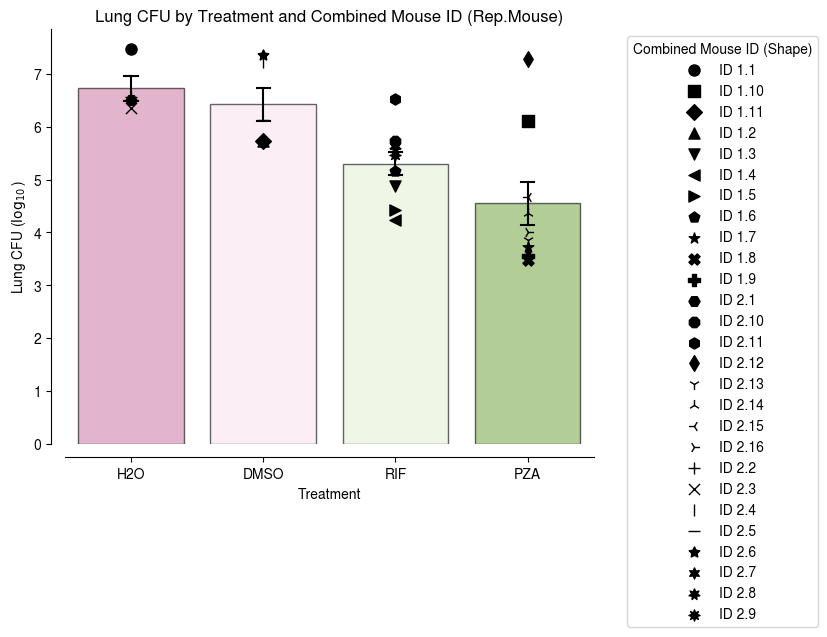

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd # Ensure pandas is imported if you are creating/modifying the DataFrame

# --- 1. Data Preparation and Mapping ---

# Ensure cfu_df is available in your notebook environment before running this code!

# 1. Ensure rep_N and mouse_N are strings for concatenation
cfu_df['rep_N'] = cfu_df['rep_N'].astype(str)
cfu_df['mouse_N'] = cfu_df['mouse_N'].astype(str)

# 2. CREATE THE NEW COMBINED COLUMN: mouse_ID = rep_N.mouse_N
cfu_df['mouse_ID'] = cfu_df['rep_N'] + '.' + cfu_df['mouse_N']

# 3. Get unique 'mouse_ID' values to build the shape map
mouse_ID_values = sorted(cfu_df['mouse_ID'].unique())
num_unique_ids = len(mouse_ID_values)

# 4. Define markers (must be long enough for all unique IDs, e.g., 11 + 16 = 27 unique IDs)
all_markers = [
    'o', 's', 'D', '^', 'v', '<', '>', 'p', '*', 'X', 'P', 'H', '8',
    'h', 'd', '1', '2', '3', '4', '+', 'x', '|', '_',
    (5, 1), (6, 1), (7, 1), (8, 1), (9, 1), (10, 1) # Adding extra custom markers
]

# 5. Create a dictionary to map 'mouse_ID' value -> marker shape
marker_map = dict(zip(mouse_ID_values, all_markers[:num_unique_ids]))

# --- 2. Setup Plot ---

plt.figure(figsize=(10, 6))
ax = plt.gca()

# 1. Bar Plot for the mean (Average CFU per Treatment)
# Using 'Treatment' for hue to color the bars based on the x-axis groups.
sns.barplot(
    data=cfu_df,
    x='Treatment',
    y='Lung CFU (log10)',
    hue='Treatment',
    ax=ax,
    errorbar=('ci', 68),
    capsize=0.1,
    alpha=0.6,
    err_kws={'color': 'black', 'linewidth': 1.5},
    edgecolor='black',
    linewidth=1,
    palette='PiYG', # Use a distinct color palette
    legend=False # Hide the redundant barplot legend
)

# 2. Scatter Plot for individual data points (Iterating for manual style)
# We iterate over the combined 'mouse_ID' groups to set the 'marker' shape
for mouse_id_val, marker_shape in marker_map.items():
    
    # Filter data for the current mouse_ID
    subset_data = cfu_df[cfu_df['mouse_ID'] == mouse_id_val]
    
    # Plot the subset with the specified marker
    sns.stripplot(
        data=subset_data,
        x='Treatment',
        y='Lung CFU (log10)',
        ax=ax,
        color='black',       # Use a single color (black) for all points for clarity
        size=8,
        jitter=5,
        linewidth=1,
        marker=marker_shape, # <-- KEY MANUAL STEP: uses combined ID for shape
        edgecolor='gray',
        # Add a label for the legend
        label=f'ID {mouse_id_val}'
    )

# --- 3. Legend Cleanup ---

# Finalize and position the legend generated by the stripplots
ax.legend(
    title='Combined Mouse ID (Shape)',
    loc='upper left',
    bbox_to_anchor=(1.05, 1)
)
sns.despine(offset=10)

# Final Touches
plt.title('Lung CFU by Treatment and Combined Mouse ID (Rep.Mouse)')
plt.xlabel('Treatment')
plt.ylabel('Lung CFU ($\log_{10}$)')
plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust to fit the legend
plt.savefig('/mnt/OPERA3/Nathan/data/macrohet/mtb_tissue_localisation/results/CFU_marker_style_separation.pdf', bbox_inches='tight', dpi=314)
plt.show()

### Previous work

In [2]:
df = pd.read_pickle('/mnt/OPERA3/Nathan/data/macrohet/mtb_tissue_localisation/results/sc_mtb_tissue.pkl')
df

,zarr_address,region_id,mean_intensity_ch1,mean_intensity_ch2,area,bbox_rmin,bbox_rmax,bbox_cmin,bbox_cmax,mouse_N,rep_N,split,condition,timer_ratio,x,y
0,20250901_40X_TimerMtb_BP_mice2_mice3_mice4_DAP...,1,669.458333,1154.916667,72.0,12,28,24285,24311,2,1,None,DMSO,0.579659,20,24298
1,20250901_40X_TimerMtb_BP_mice2_mice3_mice4_DAP...,2,394.212121,602.606061,33.0,31,46,25260,25278,2,1,None,DMSO,0.654179,38,25269
2,20250901_40X_TimerMtb_BP_mice2_mice3_mice4_DAP...,3,613.163636,943.381818,55.0,43,59,25134,25166,2,1,None,DMSO,0.649963,51,25150
3,20250901_40X_TimerMtb_BP_mice2_mice3_mice4_DAP...,4,737.836957,1462.576087,92.0,46,69,24763,24787,2,1,None,DMSO,0.504478,57,24775
4,20250901_40X_TimerMtb_BP_mice2_mice3_mice4_DAP...,5,257.228070,396.228070,57.0,47,64,27340,27364,2,1,None,DMSO,0.649192,55,27352
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
452360,rep2_mouse16_top.zarr,501,3168.583333,805.000000,156.0,34194,34228,2815,2845,16,2,top,PZA,3.936128,34211,2830
452361,rep2_mouse16_top.zarr,502,3707.631579,913.567251,171.0,34204,34231,2751,2785,16,2,top,PZA,4.058411,34217,2768
452362,rep2_mouse16_top.zarr,503,4872.142857,1180.142857,7.0,34211,34224,18594,18607,16,2,top,PZA,4.128435,34217,18600
452363,rep2_mouse16_top.zarr,504,3681.236842,837.684211,38.0,34244,34263,765,781,16,2,top,PZA,4.394540,34253,773


In [3]:
# Define the root directory to search in
root_dir = Path('/mnt/OPERA3/Nathan/data/macrohet/mtb_tissue_localisation/data/whole_slice')
dapi_seg_list=[]
for zarr_address in tqdm(df['zarr_address'].unique()):
    
    # 1. Find the full path to the Zarr file
    # We search specifically for this filename pattern within the root structure
    found_zarrs = list(root_dir.glob(f"rep*/mouse_*/zarr/{zarr_address}"))
    
    if not found_zarrs:
        print(f"⚠️ Zarr file not found on disk: {zarr_address}")
        continue
        
    zarr_path = found_zarrs[0]
    
    # 2. Check for dapi_segmentation inside the Zarr folder
    # Note: In OME-Zarr, 'labels' is a subdirectory
    # We look for any folder/file starting with 'dapi_segmentation' inside 'labels'
    dapi_seg_paths = list(zarr_path.glob("labels/dapi_segmentation*"))
    
    if dapi_seg_paths:
        print(f"✅ Found segmentation: {dapi_seg_paths[0]}")
        dapi_seg_list.append(dapi_seg_paths[0])
    else:
        print(f"❌ MISSING segmentation for: {zarr_address}")

  0%|          | 0/54 [00:00<?, ?it/s]

❌ MISSING segmentation for: 20250901_40X_TimerMtb_BP_mice2_mice3_mice4_DAPI_TimerG_TimerR_Multichannel Z-Stack_20250901_5551.zarr
❌ MISSING segmentation for: 20250901_40X_TimerMtb_BP_mice2_mice3_mice4_DAPI_TimerG_TimerR_Multichannel Z-Stack_20250901_5552.zarr
❌ MISSING segmentation for: 20250901_40X_TimerMtb_BP_mice2_mice3_mice4_DAPI_TimerG_TimerR_Multichannel Z-Stack_20250901_5553.zarr
❌ MISSING segmentation for: 20250901_40X_TimerMtb_BP_mice5_mice6_mice7_DAPI_TimerG_TimerR_Multichannel Z-Stack_20250903_5555.zarr
❌ MISSING segmentation for: 20250815_40X_TimerMtb_BP_mice1_DAPI_TimerG_TimerR_Multichannel Z-Stack_20250815_5375.zarr
✅ Found segmentation: /mnt/OPERA3/Nathan/data/macrohet/mtb_tissue_localisation/data/whole_slice/rep2/mouse_1/zarr/20251001_40X_TimerMtb_BP_rep2_mice3_mice2_mice1_DAPI_TimerG_TimerR_Multichannel Z-Stack_20251002_5574.zarr/labels/dapi_segmentation
✅ Found segmentation: /mnt/OPERA3/Nathan/data/macrohet/mtb_tissue_localisation/data/whole_slice/rep2/mouse_2/zarr/20

In [4]:
seg_path = dapi_seg_list[0]

In [5]:
# -- B. Load the Zarr Array --
try:
    # Open the Zarr array (read-only mode is safer)
    # We access the '0' scale level (highest resolution) by default in OME-Zarr
    # Adjust ['0'] if your segmentation isn't multiscaled
    z_grp = zarr.open(str(seg_path), mode='r')
    
    # OME-Zarr often stores data in a numbered subgroup like '0', '1', '2' (pyramid levels)
    # We try to grab the high-res level '0'
    if '0' in z_grp:
        dapi_mask = z_grp['0']#[:]
    else:
        # If it's a flat array (not OME-Zarr pyramid), just read it directly
        dapi_mask = z_grp#[:]
        
    # Squeeze to remove extra dimensions (e.g., T or C if they exist and are size 1)
    # e.g., (1, 1, Y, X) -> (Y, X)
    # dapi_mask = np.squeeze(dapi_mask)
    
except Exception as e:
    print(f"Error reading {seg_path}: {e}")
    # continue


Error reading /mnt/OPERA3/Nathan/data/macrohet/mtb_tissue_localisation/data/whole_slice/rep2/mouse_1/zarr/20251001_40X_TimerMtb_BP_rep2_mice3_mice2_mice1_DAPI_TimerG_TimerR_Multichannel Z-Stack_20251002_5574.zarr/labels/dapi_segmentation: name 'zarr' is not defined


In [ ]:
import gc
import re

import numpy as np
import pandas as pd
import zarr
from skimage.measure import regionprops_table
from tqdm import tqdm

# --- 1. Prepare Metadata Lookup ---
if 'condition' in df.columns:
    meta_lookup = df[['rep_N', 'mouse_N', 'condition']].drop_duplicates().set_index(['rep_N', 'mouse_N'])['condition'].to_dict()
else:
    print("⚠️ Warning: 'condition' column missing from df. Conditions will be NaN.")
    meta_lookup = {}

# Define output directory for the individual pickles
output_dir = '/mnt/OPERA3/Nathan/data/macrohet/mtb_tissue_localisation/results/dapi_pickles/'
os.makedirs(output_dir, exist_ok=True)

# --- 2. Iterate and Process (RAM SAFE) ---
print(f"Extracting nuclei coordinates from {len(dapi_seg_list)} images...")

for seg_path in tqdm(dapi_seg_list):
    
    # -- A. Extract Metadata from Path --
    match = re.search(r'/rep(\d+)/mouse_?(\d+)/', str(seg_path))
    
    if match:
        rep = int(match.group(1))
        mouse = int(match.group(2))
        condition = meta_lookup.get((rep, mouse), "Unknown")
    else:
        continue

    # -- B. Load the Zarr Array --
    try:
        z_grp = zarr.open(str(seg_path), mode='r')
        if '0' in z_grp:
            dapi_mask = z_grp['0'][:]
        else:
            dapi_mask = z_grp[:]
        
        dapi_mask = np.squeeze(dapi_mask)
        
    except Exception as e:
        print(f"Error reading {seg_path}: {e}")
        continue

    # -- C. Extract Centroids --
    try:
        props = regionprops_table(dapi_mask, properties=('label', 'centroid'))
        
        # Create a temporary DataFrame
        temp_df = pd.DataFrame(props)
        
        # Free up the mask memory immediately
        del dapi_mask
        
        if 'centroid-0' in temp_df.columns and 'centroid-1' in temp_df.columns:
            temp_df = temp_df.rename(columns={'centroid-0': 'y', 'centroid-1': 'x'})
            
            # Add metadata columns
            temp_df['rep_N'] = rep
            temp_df['mouse_N'] = mouse
            temp_df['condition'] = condition
            
            # Extract Zarr Filename for unique saving
            parent_zarr = pd.Series(str(seg_path)).str.extract(r'([^/]+\.zarr)')[0][0]
            temp_df['zarr_address'] = parent_zarr
            
            # -- SAVE IMMEDIATELY --
            # Use zarr name to ensure uniqueness (avoids overwrites)
            save_path = os.path.join(output_dir, f"{parent_zarr}_nuclei.pkl")
            temp_df.to_pickle(save_path)
            
            # -- CLEANUP --
            del temp_df
            del props
            gc.collect() # Force Python to release memory
            
    except ValueError:
        continue
    except Exception as e:
        print(f"Error processing {seg_path}: {e}")
        continue

print("Done! All files saved individually.")

Extracting nuclei coordinates from 16 images...


  0%|                                                                                           | 0/16 [00:00<?, ?it/s]

In [ ]:
yabbadabbado

In [ ]:
import os
import re

import numpy as np
import pandas as pd
import zarr

# from tqdm import tqdm
from skimage.measure import regionprops_table

# --- 1. Prepare Metadata Lookup ---
# Create a dictionary to quickly find 'condition' based on (rep, mouse)
# This prevents us from having to do slow merges later.
# Format: { (1, 2): 'H2O', (1, 3): 'DMSO', ... }
if 'condition' in df.columns:
    meta_lookup = df[['rep_N', 'mouse_N', 'condition']].drop_duplicates().set_index(['rep_N', 'mouse_N'])['condition'].to_dict()
else:
    print("⚠️ Warning: 'condition' column missing from df. Conditions will be NaN.")
    meta_lookup = {}

nuclei_data_list = []

# --- 2. Iterate and Process ---
print(f"Extracting nuclei coordinates from {len(dapi_seg_list)} images...")

for seg_path in tqdm(dapi_seg_list):
    
    # -- A. Extract Metadata from Path --
    # We use the full path string to find Rep and Mouse numbers
    # Regex looks for /repX/ and /mouse_Y/
    match = re.search(r'/rep(\d+)/mouse_?(\d+)/', str(seg_path))
    
    if match:
        rep = int(match.group(1))
        mouse = int(match.group(2))
        condition = meta_lookup.get((rep, mouse), "Unknown")
    else:
        print(f"Skipping (Metadata not found in path): {seg_path}")
        continue

    # -- B. Load the Zarr Array --
    try:
        # Open the Zarr array (read-only mode is safer)
        # We access the '0' scale level (highest resolution) by default in OME-Zarr
        # Adjust ['0'] if your segmentation isn't multiscaled
        z_grp = zarr.open(str(seg_path), mode='r')
        
        # OME-Zarr often stores data in a numbered subgroup like '0', '1', '2' (pyramid levels)
        # We try to grab the high-res level '0'
        if '0' in z_grp:
            dapi_mask = z_grp['0'][:]
        else:
            # If it's a flat array (not OME-Zarr pyramid), just read it directly
            dapi_mask = z_grp[:]
            
        # Squeeze to remove extra dimensions (e.g., T or C if they exist and are size 1)
        # e.g., (1, 1, Y, X) -> (Y, X)
        dapi_mask = np.squeeze(dapi_mask)
        
    except Exception as e:
        print(f"Error reading {seg_path}: {e}")
        continue

    # -- C. Extract Centroids --
    # regionprops_table is much faster than looping through regions
    try:
        props = regionprops_table(dapi_mask, properties=('label', 'centroid'))
        
        # Create a temporary DataFrame
        temp_df = pd.DataFrame(props)
        
        # Rename columns standard names (centroid-0 is Y, centroid-1 is X)
        # Note: If 3D, you might get centroid-0 (Z), -1 (Y), -2 (X). Check shape!
        if 'centroid-0' in temp_df.columns and 'centroid-1' in temp_df.columns:
            temp_df = temp_df.rename(columns={'centroid-0': 'y', 'centroid-1': 'x'})
            
            # Add metadata columns
            temp_df['rep_N'] = rep
            temp_df['mouse_N'] = mouse
            temp_df['condition'] = condition
            
            # Store the basename of the Zarr for reference
            # Assuming seg_path is .../filename.zarr/labels/dapi_segmentation
            # We go up 3 levels to find the .zarr folder name
            parent_zarr = pd.Series(str(seg_path)).str.extract(r'([^/]+\.zarr)')[0][0]
            temp_df['zarr_address'] = parent_zarr
            
            nuclei_data_list.append(temp_df)
        temp_df.to_pickle(f'/mnt/OPERA3/Nathan/data/macrohet/mtb_tissue_localisation/results/dapi_coords_rep{rep}_mouse{mouse}.pkl')
    except ValueError:
        # Happens if mask is empty
        continue

# --- 3. Combine into Final DataFrame ---
if nuclei_data_list:
    nuclei_df = pd.concat(nuclei_data_list, ignore_index=True)
    print("Done!")
    print(nuclei_df.head())
else:
    print("No nuclei data extracted.")